## BOOSTING ALGORITHMS PROJECT

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


from sklearn.tree import plot_tree

## STEP 1 - Load dataset and setup our training-testing splits

In [2]:
df= pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=421&path=diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
# create train and test set splits
train_df, test_df = train_test_split(df, test_size=0.25, random_state=4)

In [5]:
# assign X and y for both train and test sets
X_train = train_df.drop(columns=['Outcome'])
y_train = train_df['Outcome']

X_test = test_df.drop(columns=['Outcome'])
y_test = test_df['Outcome']

In [6]:
# this function makes predictions and prints out various evaluation metrics
def model_evaluator(X_matrix, y_target, model):
    preds = model.predict(X_matrix)
    
    print(f"Accuracy score: {round(accuracy_score(y_true = y_target, y_pred = preds),4)}")
    print(f"Precision score: {round(precision_score(y_true = y_target, y_pred = preds),4)}")
    print(f"Recall score: {round(recall_score(y_true = y_target, y_pred = preds),4)}")
    print(f"F1 score:{round(f1_score(y_true = y_target, y_pred = preds),4)}")
    print(f"Confusion matrix: \n{confusion_matrix(y_true = y_target, y_pred = preds)}")
    print(f"Classification report: \n{classification_report(y_true = y_target, y_pred = preds)}")

## Random Forest Model - Baseline

In [7]:
# assign RandomForestClassifier model to a variable - random state to set to make our results reproducible
rf_model = RandomForestClassifier(random_state=101)

# 'fit' our train data to our classifier for predictions
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# evaluate the model on the training set using the function we created above
model_evaluator(X_train, y_train, rf_model)

Accuracy score: 1.0
Precision score: 1.0
Recall score: 1.0
F1 score:1.0
Confusion matrix: 
[[374   0]
 [  0 202]]
Classification report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       374
           1       1.00      1.00      1.00       202

    accuracy                           1.00       576
   macro avg       1.00      1.00      1.00       576
weighted avg       1.00      1.00      1.00       576



In [9]:
# evaluate the model on the test set
model_evaluator(X_test, y_test, rf_model)

Accuracy score: 0.7604
Precision score: 0.6515
Recall score: 0.6515
F1 score:0.6515
Confusion matrix: 
[[103  23]
 [ 23  43]]
Classification report: 
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       126
           1       0.65      0.65      0.65        66

    accuracy                           0.76       192
   macro avg       0.73      0.73      0.73       192
weighted avg       0.76      0.76      0.76       192



## STEP 2 - Build a boosting model - Gradient / XGBoost

## Now we start Gradient Boosting

## 1st model comes from sci-kit learn

In [10]:
gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [11]:
model_evaluator(X_train, y_train, gb_model)

Accuracy score: 0.9392
Precision score: 0.9372
Recall score: 0.8861
F1 score:0.9109
Confusion matrix: 
[[362  12]
 [ 23 179]]
Classification report: 
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       374
           1       0.94      0.89      0.91       202

    accuracy                           0.94       576
   macro avg       0.94      0.93      0.93       576
weighted avg       0.94      0.94      0.94       576



In [12]:
model_evaluator(X_test, y_test, gb_model)

Accuracy score: 0.7812
Precision score: 0.6714
Recall score: 0.7121
F1 score:0.6912
Confusion matrix: 
[[103  23]
 [ 19  47]]
Classification report: 
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       126
           1       0.67      0.71      0.69        66

    accuracy                           0.78       192
   macro avg       0.76      0.76      0.76       192
weighted avg       0.78      0.78      0.78       192



In [13]:
# n_esimators: number of trees in the forest
# max_depth: maximum depth of the tree
# min_samples_split: minimum number of samples required to split an internal node
# min_samples_leaf: minimum number of samples required to be at a leaf node

hyperparameter_dict = {'n_estimators': [50, 100],
                       'max_depth': [None,10],
                       'min_samples_split': [2, 8],
                       'min_samples_leaf': [4, 8],
                       'learning_rate': [0.01, 0.1, 0.2]
                       }

In [14]:
gridsearch_model = GridSearchCV(estimator=GradientBoostingClassifier(),
                                param_grid = hyperparameter_dict,
                                scoring = 'accuracy',
                                verbose=3,
                                cv=4)

In [15]:
gridsearch_model.fit(X_train, y_train)

Fitting 4 folds for each of 48 candidates, totalling 192 fits


[CV 1/4] END learning_rate=0.01, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=50;, score=0.757 total time=   0.4s
[CV 2/4] END learning_rate=0.01, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=50;, score=0.674 total time=   0.2s
[CV 3/4] END learning_rate=0.01, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=50;, score=0.715 total time=   0.2s
[CV 4/4] END learning_rate=0.01, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=50;, score=0.785 total time=   0.2s
[CV 1/4] END learning_rate=0.01, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100;, score=0.778 total time=   0.4s
[CV 2/4] END learning_rate=0.01, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100;, score=0.708 total time=   0.4s
[CV 3/4] END learning_rate=0.01, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100;, score=0.722 total time=   0.4s
[CV 4/4] END learning_ra

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [None, 10], 'min_samples_leaf': [4, 8], 'min_samples_split': [2, 8], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,4
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [16]:
model_evaluator(X_train, y_train, gridsearch_model.best_estimator_)

Accuracy score: 1.0
Precision score: 1.0
Recall score: 1.0
F1 score:1.0
Confusion matrix: 
[[374   0]
 [  0 202]]
Classification report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       374
           1       1.00      1.00      1.00       202

    accuracy                           1.00       576
   macro avg       1.00      1.00      1.00       576
weighted avg       1.00      1.00      1.00       576



In [17]:
model_evaluator(X_test, y_test, gridsearch_model.best_estimator_)

Accuracy score: 0.7917
Precision score: 0.697
Recall score: 0.697
F1 score:0.697
Confusion matrix: 
[[106  20]
 [ 20  46]]
Classification report: 
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       126
           1       0.70      0.70      0.70        66

    accuracy                           0.79       192
   macro avg       0.77      0.77      0.77       192
weighted avg       0.79      0.79      0.79       192



### 2nd model comes from XGBoost

In [18]:
from xgboost import XGBClassifier

In [19]:
xgb_model = XGBClassifier()

In [20]:
hyperparameter_dict = {'n_estimators': [50, 100, 200],
                       'learning_rate': [0.01, 0.1, 1, 10],
                       'booster': ['gbtree', 'gblinear']
                       }

In [21]:
xgb_gridsearch_model = GridSearchCV(estimator=XGBClassifier(),
                                    param_grid=hyperparameter_dict,
                                    scoring='accuracy',
                                    )
                                    

In [22]:
xgb_gridsearch_model.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'booster': ['gbtree', 'gblinear'], 'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [23]:
model_evaluator(X_train, y_train, xgb_gridsearch_model.best_estimator_)

Accuracy score: 0.7674
Precision score: 0.7048
Recall score: 0.5792
F1 score:0.6359
Confusion matrix: 
[[325  49]
 [ 85 117]]
Classification report: 
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       374
           1       0.70      0.58      0.64       202

    accuracy                           0.77       576
   macro avg       0.75      0.72      0.73       576
weighted avg       0.76      0.77      0.76       576



In [24]:
model_evaluator(X_test, y_test, xgb_gridsearch_model.best_estimator_)

Accuracy score: 0.7969
Precision score: 0.7213
Recall score: 0.6667
F1 score:0.6929
Confusion matrix: 
[[109  17]
 [ 22  44]]
Classification report: 
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       126
           1       0.72      0.67      0.69        66

    accuracy                           0.80       192
   macro avg       0.78      0.77      0.77       192
weighted avg       0.79      0.80      0.79       192



In [25]:
xgb_gridsearch_model.best_params_

{'booster': 'gblinear', 'learning_rate': 1, 'n_estimators': 50}

In [26]:
xgb_gridsearch_model.best_estimator_.coef_

array([ 2.26160e-01,  3.04380e-02, -2.68769e-02, -1.10682e-02,
        2.27619e-04,  1.00890e-01,  9.62174e-01, -1.63692e-02])

In [27]:
temp_df = pd.DataFrame({
    'Feature': xgb_gridsearch_model.feature_names_in_,
    'Importance': xgb_gridsearch_model.best_estimator_.feature_importances_,
    'Coefficient': xgb_gridsearch_model.best_estimator_.coef_
})

temp_df

,Feature,Importance,Coefficient
0,Pregnancies,0.178701,0.226160
1,Glucose,0.024051,0.030438
2,BloodPressure,-0.021237,-0.026877
3,SkinThickness,-0.008746,-0.011068
4,Insulin,0.000180,0.000228
5,BMI,0.079719,0.100890
6,DiabetesPedigreeFunction,0.760266,0.962174
7,Age,-0.012934,-0.016369


## Modifying hyperparameters to see if we can get better results

Modifying the GradientBoostingClassifier - This did better than the first one we did.

In [28]:
hyperparameter_dict = {'n_estimators': [100, 200, 300],
                       'learning_rate': [0.01, 0.05, 0.1],
                       'max_depth': [2, 3],
                       'min_samples_split': [2, 5],
                       'min_samples_leaf': [1, 2],
                       'subsample': [0.8, 1.0]
}

In [29]:
gb_gridsearch_model = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42),
                                param_grid = hyperparameter_dict,
                                scoring = 'accuracy',
                                verbose=2,
                                cv=4,
                                n_jobs=-1) #speeds up CPU processing time

In [30]:
gb_gridsearch_model.fit(X_train, y_train)

Fitting 4 folds for each of 144 candidates, totalling 576 fits


[CV] END learning_rate=0.01, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.01, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END learning_rate=0.01, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.01, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.01, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END learning_rate=0.01, max_depth=2, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END learning_rate=0.01, max_depth=2, min_samples_l

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,4
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [31]:
model_evaluator(X_train, y_train, gb_gridsearch_model.best_estimator_)

Accuracy score: 0.8264
Precision score: 0.8072
Recall score: 0.6634
F1 score:0.7283
Confusion matrix: 
[[342  32]
 [ 68 134]]
Classification report: 
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       374
           1       0.81      0.66      0.73       202

    accuracy                           0.83       576
   macro avg       0.82      0.79      0.80       576
weighted avg       0.82      0.83      0.82       576



We are not overfitting.  Test did better than train

In [32]:
model_evaluator(X_test, y_test, gb_gridsearch_model.best_estimator_)

Accuracy score: 0.8177
Precision score: 0.746
Recall score: 0.7121
F1 score:0.7287
Confusion matrix: 
[[110  16]
 [ 19  47]]
Classification report: 
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       126
           1       0.75      0.71      0.73        66

    accuracy                           0.82       192
   macro avg       0.80      0.79      0.80       192
weighted avg       0.82      0.82      0.82       192



In [33]:
## Gradient Boosting heatmap of baseline model vs modified model (train/test)

Modifying the XGBooster for better performance

In [34]:
hyperparameter_dict = {'n_estimators': [100, 200, 300],
                       'learning_rate': [0.01, 0.05, 0.1],
                       'max_depth': [2, 3, 4],
                       'min_child_weight': [1, 3, 5],
                       'subsample': [0.8, 1.0],
                       'colsample_bytree': [0.8, 1.0],
                       'gamma': [0, 0.1, 0.3]
                       }

In [35]:
xgb_gridsearch_model = GridSearchCV(estimator=XGBClassifier(),
                                    param_grid=hyperparameter_dict,
                                    scoring='accuracy',
                                    verbose=2,
                                    cv=4,
                                    n_jobs=-1
                                    )

In [36]:
xgb_gridsearch_model.fit(X_train, y_train)

Fitting 4 folds for each of 972 candidates, totalling 3888 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.0s


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=200, subsample=1.0; tota

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,4
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [37]:
model_evaluator(X_train, y_train, xgb_gridsearch_model.best_estimator_)

Accuracy score: 0.8524
Precision score: 0.8503
Recall score: 0.703
F1 score:0.7696
Confusion matrix: 
[[349  25]
 [ 60 142]]
Classification report: 
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       374
           1       0.85      0.70      0.77       202

    accuracy                           0.85       576
   macro avg       0.85      0.82      0.83       576
weighted avg       0.85      0.85      0.85       576



In [38]:
model_evaluator(X_test, y_test, xgb_gridsearch_model.best_estimator_)

Accuracy score: 0.7917
Precision score: 0.7097
Recall score: 0.6667
F1 score:0.6875
Confusion matrix: 
[[108  18]
 [ 22  44]]
Classification report: 
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       126
           1       0.71      0.67      0.69        66

    accuracy                           0.79       192
   macro avg       0.77      0.76      0.77       192
weighted avg       0.79      0.79      0.79       192



In [39]:
## XGB heatmap of baseline model vs modified model (train/test)

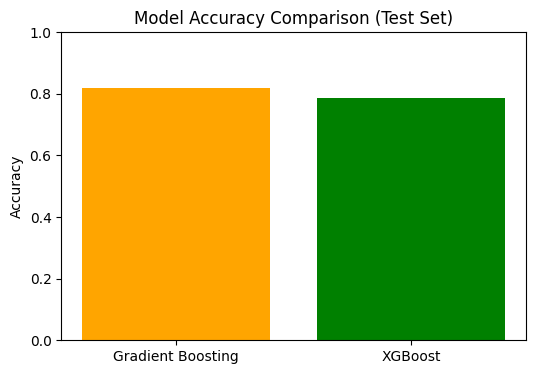

In [40]:
models = ['Gradient Boosting', 'XGBoost']
accuracy = [0.818, 0.786]   # your test accuracies

plt.figure(figsize=(6,4))
plt.bar(models, accuracy, color=['orange', 'green'])
plt.title("Model Accuracy Comparison (Test Set)")
plt.ylabel("Accuracy")
plt.ylim(0,1) #control range
plt.show()

Our Gradient booster did a little better than the XGBooster model modifications

In [41]:
# assign RandomForestClassifier model to a variable - random state to set to make our results reproducible
rf_modified = RandomForestClassifier(random_state=101)


In [42]:
hyperparameters_dict = {'n_estimators': [100, 200, 500],
                        'max_depth': [None, 5, 10],
                        'min_samples_split': [2, 5, 10],
                        'min_samples_leaf': [1, 2, 4],
                        'max_features': ['sqrt', 'log2'],
                        'bootstrap': [True, False]
                        }

In [43]:
rf_modified_gridsearch_model = GridSearchCV(estimator=rf_modified,
                                   param_grid=hyperparameters_dict,
                                   scoring='accuracy', 
                                   cv=4,
                                   verbose=3,
                                   n_jobs=-1
                                   )

In [44]:
rf_modified_gridsearch_model.fit(X_train, y_train)

Fitting 4 folds for each of 324 candidates, totalling 1296 fits
[CV 1/4] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.778 total time=   0.4s
[CV 2/4] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.778 total time=   0.4s
[CV 3/4] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.771 total time=   0.2s
[CV 4/4] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.771 total time=   0.2s
[CV 1/4] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.771 total time=   0.4s
[CV 2/4] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.764 total time=   0.4s
[CV 3/

,estimator,RandomForestC...dom_state=101)
,param_grid,"{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,4
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [45]:
model_evaluator(X_train, y_train, rf_modified_gridsearch_model.best_estimator_)

Accuracy score: 0.9809
Precision score: 0.9799
Recall score: 0.9653
F1 score:0.9726
Confusion matrix: 
[[370   4]
 [  7 195]]
Classification report: 
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       374
           1       0.98      0.97      0.97       202

    accuracy                           0.98       576
   macro avg       0.98      0.98      0.98       576
weighted avg       0.98      0.98      0.98       576



In [46]:
model_evaluator(X_test, y_test, rf_modified_gridsearch_model.best_estimator_)

Accuracy score: 0.7865
Precision score: 0.6712
Recall score: 0.7424
F1 score:0.705
Confusion matrix: 
[[102  24]
 [ 17  49]]
Classification report: 
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       126
           1       0.67      0.74      0.71        66

    accuracy                           0.79       192
   macro avg       0.76      0.78      0.77       192
weighted avg       0.79      0.79      0.79       192



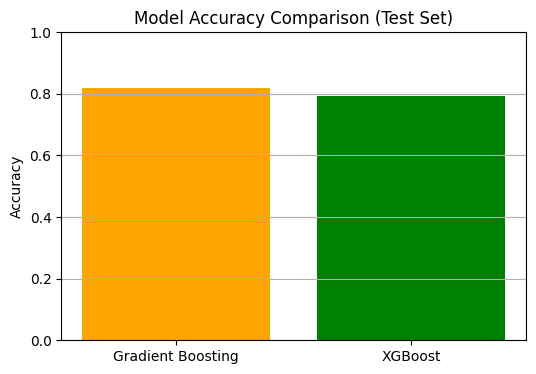

In [47]:
models = ['Gradient Boosting', 'XGBoost']

gb_accuracy = accuracy_score(y_test, gb_gridsearch_model.best_estimator_.predict(X_test))
xgb_accuracy = accuracy_score(y_test, xgb_gridsearch_model.best_estimator_.predict(X_test))

accuracies = [gb_accuracy, xgb_accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies, color=['orange', 'green'])
plt.title("Model Accuracy Comparison (Test Set)")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

## XGBoost and Random Forest did about the same, Gradient Boosting still did the best

## STEP 3: Save modified models

In [48]:
import pickle

In [49]:
# 'with' handles saving the project safer
# wb = write binary
# f is my open file — write into it
with open('../models/gradient_boosting_diabetes.pkl', 'wb') as f:
    pickle.dump(gb_gridsearch_model.best_estimator_, f)

# STEP 4: Analyze and compare all models

CONFUSION MATRIX COMPARISONS

    Compare all modfied Confusion Matrix

In [50]:
from sklearn.metrics import confusion_matrix

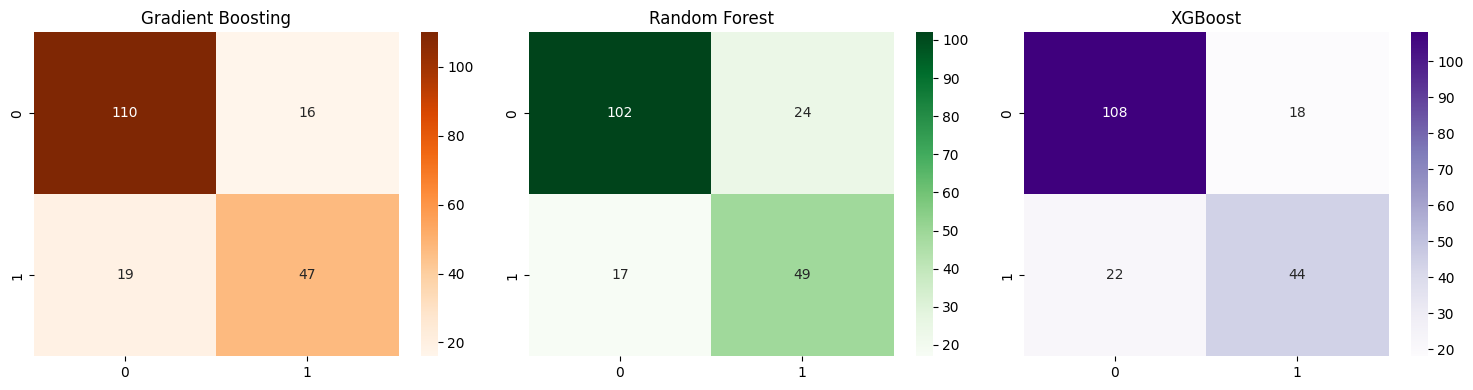

In [51]:
gb_pred = gb_gridsearch_model.best_estimator_.predict(X_test)
rf_pred  = rf_modified_gridsearch_model.best_estimator_.predict(X_test)
xgb_pred = xgb_gridsearch_model.best_estimator_.predict(X_test)

# Confusion Matrices
gb_cm  = confusion_matrix(y_test, gb_pred)
rf_cm  = confusion_matrix(y_test, rf_pred)
xgb_cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.heatmap(gb_cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Gradient Boosting")

plt.subplot(1,3,2)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest")

plt.subplot(1,3,3)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Purples')
plt.title("XGBoost")

plt.tight_layout()
plt.show()

##    Recall old models and compare against new modified models

In [52]:
import joblib

Decision Tree

    I Couldnt load this model evaluator because I created custom columns.  In a situation like this we must stay consistant

Random Forest - from pervious project (Random Forest)

    I pulled the one from our previous project to compare it to the one I ran in this project.  
    Both are very close so I went with the one I ran in this project.

In [53]:
# results from best Random Forest project
rf_model_imported = joblib.load("../random_forest_best.pkl")


In [54]:
model_evaluator(X_test, y_test, rf_model_imported)

Accuracy score: 0.7917
Precision score: 0.6912
Recall score: 0.7121
F1 score:0.7015
Confusion matrix: 
[[105  21]
 [ 19  47]]
Classification report: 
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       126
           1       0.69      0.71      0.70        66

    accuracy                           0.79       192
   macro avg       0.77      0.77      0.77       192
weighted avg       0.79      0.79      0.79       192



In [55]:
from sklearn.metrics import classification_report

In [56]:
def get_model_metrics(model, X, y, model_name):
    preds = model.predict(X) # calls each models predict
    report = classification_report(y, preds, output_dict=True) # runs the classification_report on y and preds
    
    return {
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision (Class 1)": report["1"]["precision"],
        "Recall (Class 1)": report["1"]["recall"],
        "F1-score (Class 1)": report["1"]["f1-score"]
    }

In [57]:
# In this dataset, class 1 represents diabetic (positive) cases.
# The metrics below focus on how effectively each model identifies these cases, particularly recall, 
# which measures the percentage of actual diabetic patients that were correctly predicted.

results = []

results.append(get_model_metrics(rf_model_imported, X_test, y_test, "Random Forest"))
results.append(get_model_metrics(gb_gridsearch_model.best_estimator_, X_test, y_test, "Gradient Boosting"))
results.append(get_model_metrics(xgb_gridsearch_model.best_estimator_, X_test, y_test, "XGBoost"))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (Class 1),Recall (Class 1),F1-score (Class 1)
0,Random Forest,0.791667,0.691176,0.712121,0.701493
1,Gradient Boosting,0.817708,0.746032,0.712121,0.728682
2,XGBoost,0.791667,0.709677,0.666667,0.687500


## GRADIENT BOOSTING HAD THE BEST RESULTS ON THIS TEST SET